# Missing Values I — finding the blanks and filling them sensibly

01 Core Python · 02 Pandas · **▶ 03 Cleaning** · 04 Transformation · 05 Feature Engineering · 06 Regression · 07 Model Prep · 08 Case Studies

`03_Data_Cleaning/01_missing_values_univariate.ipynb`

---

### In one paragraph (no jargon)

Almost no real dataset is complete. Someone skipped a survey question, a sensor dropped out, a field wasn't mandatory. Pandas marks every such gap as `NaN`, and almost every calculation quietly ignores them — which means a mean computed over a column that's 30% empty is a mean of the 70% who answered, and that may be a very different group. This notebook covers finding the gaps, deciding what they mean, and the standard ways of filling them.

### After this notebook you can

- Count and visualise missing values, per column and per row
- Choose between dropping and filling, and justify the choice
- Fill numeric columns with mean/median, and text columns with the mode
- Use forward-fill and interpolation for ordered data
- Keep a missing-indicator so the fact of the gap isn't lost


### What's inside

1. Setup and first look
2. Visualising missingness
3. Deletion methods
4. Simple imputation for numbers
5. Forward-fill and interpolation
6. Categorical imputation
7. Missing indicators
8. Every technique compared
9. Decision guide
10. Exam quick-reference

---

> **▶ Runs on its own.** The next cell is the only setup you need. It imports the
> libraries and loads the data. If the `datasets/` folder isn't where it expects,
> it rebuilds an equivalent dataset in memory so **every cell below still runs** —
> handy if you copy this single `.ipynb` somewhere else.
>
> **▶ Reading the cells.** Code comments explain *what the line does*; the text
> blocks explain *why you'd do it*. Look for these markers:
> `# WHAT:` a plain-English translation · `# WHY:` the reason it matters ·
> `# 🔧 CHANGE THIS:` the knob to turn when the exam question differs ·
> **⚡ Beyond the syllabus** = optional, higher-mark techniques.

### Jargon buster

| Term | Plain English |
|---|---|
| **NaN** | "Not a Number" — pandas' marker for an empty cell. It is *not* zero and *not* the text "NA". |
| **Imputation** | Filling a blank with an estimated value. |
| **Univariate imputation** | Estimating the blank using only that one column (its mean, median or mode). |
| **Multivariate imputation** | Estimating it using the *other* columns too (KNN, regression, MICE). |
| **Listwise deletion** | Deleting any row that has a blank anywhere. Simple, but throws away good data. |
| **MCAR / MAR / MNAR** | *Missing Completely At Random* (safe to drop) · *Missing At Random* — predictable from other columns (impute) · *Missing Not At Random* — the blank itself is meaningful (flag it, never silently fill). |
| **Missing indicator** | An extra True/False column recording *that* a value was missing, kept alongside the filled value. |

In [1]:
# =============================================================================
# SETUP — run this cell first. It is the only cell with dependencies.
# =============================================================================
# WHAT: `import` pulls in code other people have written so we don't rewrite it.
#       The `as pd` part is a nickname, so we can type `pd` instead of `pandas`.
import pandas as pd          # tables of data (think: Excel, but programmable)
import numpy as np           # fast maths on whole columns at once
import matplotlib.pyplot as plt   # charts
import warnings

warnings.filterwarnings('ignore')          # hide version-upgrade notices, keeps output readable
pd.set_option('display.max_columns', 50)   # don't hide columns behind "..."
pd.set_option('display.width', 160)
import os
import seaborn as sns
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------------------------
# `missingno` draws missing-value maps. It is a small optional library, so if it
# isn't installed we substitute an equivalent drawn with matplotlib. Either way
# every cell below runs and produces the same picture.
# ---------------------------------------------------------------------------
try:
    import missingno as msno
    print("Using the missingno library.")
except ImportError:
    print("missingno not installed - using the built-in equivalent below.")

    class _MissingnoFallback:
        """Drop-in replacement for the few missingno functions used here."""

        @staticmethod
        def matrix(frame, figsize=(10, 4), **kw):
            fig, ax = plt.subplots(figsize=figsize)
            # white = value present, dark = value missing
            ax.imshow(frame.notna().to_numpy(), aspect='auto', cmap='binary_r',
                      interpolation='nearest')
            ax.set_xticks(range(frame.shape[1]))
            ax.set_xticklabels(frame.columns, rotation=45, ha='right', fontsize=8)
            ax.set_ylabel('row')
            ax.set_title('Missing-value map  (dark = missing)', fontsize=11)
            plt.tight_layout()
            return ax

        @staticmethod
        def bar(frame, figsize=(10, 4), **kw):
            fig, ax = plt.subplots(figsize=figsize)
            completeness = frame.notna().mean().sort_values()
            ax.bar(completeness.index, completeness.values, color='#4c72b0')
            ax.set_ylim(0, 1.05)
            ax.set_ylabel('proportion present')
            ax.set_title('Completeness by column', fontsize=11)
            plt.xticks(rotation=45, ha='right', fontsize=8)
            plt.tight_layout()
            return ax

        @staticmethod
        def heatmap(frame, figsize=(7, 5), **kw):
            gaps = frame.columns[frame.isna().any()]
            fig, ax = plt.subplots(figsize=figsize)
            if len(gaps) < 2:
                ax.text(.5, .5, 'Fewer than two columns have gaps,\nso there is no co-occurrence to show.',
                        ha='center', va='center')
                ax.axis('off')
                return ax
            sns.heatmap(frame[gaps].isna().corr(), annot=True, fmt='.2f',
                        cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
            ax.set_title('Do gaps occur together?', fontsize=11)
            plt.tight_layout()
            return ax

        @staticmethod
        def dendrogram(frame, **kw):
            return _MissingnoFallback.heatmap(frame)

    msno = _MissingnoFallback()

def find_datasets_folder(start=None):
    """Walk upwards from this notebook looking for the shared `datasets/` folder.

    WHY: it means the notebook works whether you opened it from its own folder,
    from the top of the notes, or from anywhere else on your machine.
    """
    here = os.path.abspath(start or os.getcwd())
    for _ in range(6):                       # look up to 6 folders up
        candidate = os.path.join(here, 'datasets')
        if os.path.isdir(candidate):
            return candidate
        parent = os.path.dirname(here)
        if parent == here:
            break
        here = parent
    return None

def dataset_path(filename, rebuild=None):
    """Return a real path to `filename`, materialising a temp copy if it's missing.

    WHY: a few pandas tools (pd.ExcelFile, pd.read_sql) need an actual file path
         rather than a DataFrame, so the fallback has to be written to disk.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            return path
    if rebuild is None:
        raise FileNotFoundError(filename)
    import tempfile
    tmp = os.path.join(tempfile.mkdtemp(prefix='bda_'), filename)
    frame = rebuild()
    (frame.to_excel(tmp, index=False) if filename.lower().endswith(('.xlsx', '.xls'))
     else frame.to_csv(tmp, index=False))
    print(f"'{filename}' not found -> wrote a rebuilt copy to {tmp}")
    return tmp

def load_data(filename, rebuild=None, **read_kwargs):
    """Load `filename` from the shared datasets folder, or rebuild it in memory.

    WHAT: tries to read the real file; if it can't find it, calls `rebuild()`
          which recreates a dataset with the same columns and behaviour.
    WHY:  guarantees this notebook runs even if the CSV goes missing.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            reader = pd.read_excel if filename.lower().endswith(('.xlsx', '.xls')) else pd.read_csv
            print(f"Loaded '{filename}' from {folder}")
            return reader(path, **read_kwargs)
    if rebuild is None:
        raise FileNotFoundError(f"Could not find {filename} and no fallback was supplied.")
    print(f"'{filename}' not found on disk -> rebuilding an equivalent dataset in memory.")
    built = rebuild()
    if 'chunksize' in read_kwargs:            # keep chunked reads working on the fallback path
        size = read_kwargs['chunksize']
        return (built.iloc[i:i + size] for i in range(0, len(built), size))
    return built

def rebuild_customer_data():
    """Exact copy of customer_data.csv, embedded so this notebook never needs the file."""
    import io
    csv_text = """Customer_ID,Age,Gender,Income,Purchase_Amount,Region
1,55.0,Male,70000.0,2400.0,West
2,45.0,Male,65000.0,1900.0,North
3,31.0,Male,30000.0,2400.0,East
4,59.0,Female,50000.0,1400.0,
5,24.0,Female,70000.0,4000.0,East
6,37.0,,20000.0,3900.0,West
7,55.0,Male,25000.0,3800.0,South
8,35.0,Female,70000.0,2200.0,West
9,39.0,Female,,2300.0,East
10,27.0,Male,,2100.0,West
11,27.0,Female,75000.0,4400.0,North
12,40.0,Female,25000.0,1700.0,North
13,52.0,Female,65000.0,1800.0,North
14,56.0,Male,35000.0,3400.0,East
15,40.0,Male,70000.0,,West
16,19.0,Female,25000.0,600.0,West
17,38.0,Female,,1900.0,North
18,18.0,Male,,2600.0,West
19,40.0,Male,50000.0,1400.0,South
20,46.0,,60000.0,1500.0,South
21,54.0,Male,65000.0,1300.0,North
22,18.0,Female,70000.0,3500.0,West
23,37.0,Female,75000.0,1900.0,North
24,49.0,Female,75000.0,1100.0,East
25,28.0,Female,70000.0,4100.0,West
26,38.0,Male,20000.0,1500.0,North
27,41.0,Female,75000.0,2700.0,East
28,43.0,Female,25000.0,3100.0,South
29,58.0,Male,20000.0,1100.0,South
30,44.0,Male,25000.0,3100.0,East
31,32.0,,45000.0,3900.0,South
32,31.0,Female,,2900.0,East
33,19.0,Male,60000.0,1100.0,East
34,53.0,,50000.0,3100.0,East
35,23.0,,75000.0,3100.0,West
36,37.0,Female,60000.0,4000.0,East
37,25.0,Female,60000.0,4400.0,East
38,55.0,Male,60000.0,3900.0,East
39,34.0,Male,20000.0,3000.0,South
40,20.0,Female,25000.0,2000.0,South
41,41.0,Female,55000.0,1200.0,West
42,30.0,Female,45000.0,3600.0,East
43,25.0,Male,30000.0,2300.0,South
44,42.0,Female,60000.0,1600.0,East
45,18.0,Female,35000.0,3100.0,South
46,36.0,,20000.0,3200.0,West
47,44.0,Female,75000.0,1600.0,North
48,23.0,Female,65000.0,4900.0,South
49,24.0,Female,75000.0,3800.0,South
50,51.0,Male,50000.0,900.0,East
51,30.0,,30000.0,2100.0,West
52,33.0,,55000.0,800.0,North
53,52.0,Male,35000.0,2800.0,West
54,56.0,Male,75000.0,500.0,North
55,20.0,Female,55000.0,1300.0,West
56,18.0,Male,30000.0,3300.0,North
57,22.0,,60000.0,4800.0,North
58,58.0,Male,35000.0,800.0,East
59,20.0,Male,55000.0,3600.0,
60,45.0,Female,50000.0,,West
61,34.0,Male,25000.0,2100.0,East
62,42.0,Male,,3500.0,West
63,50.0,Female,25000.0,1400.0,North
64,26.0,Female,30000.0,2400.0,
65,52.0,Male,20000.0,2900.0,East
66,30.0,Female,,2800.0,West
67,47.0,Female,45000.0,2500.0,West
68,31.0,Female,50000.0,3000.0,West
69,24.0,Male,45000.0,1600.0,East
70,30.0,Female,35000.0,3600.0,East
71,39.0,,70000.0,3700.0,West
72,56.0,Female,,4400.0,South
73,37.0,,45000.0,3800.0,
74,32.0,Male,75000.0,,West
75,34.0,Male,45000.0,2400.0,North
76,40.0,Female,55000.0,900.0,West
77,42.0,Female,25000.0,3100.0,East
78,41.0,Female,55000.0,2000.0,West
79,57.0,Male,,800.0,West
80,45.0,Female,,3400.0,North
81,31.0,Female,30000.0,800.0,East
82,,Female,55000.0,4100.0,West
83,41.0,Male,40000.0,600.0,South
84,23.0,,75000.0,2600.0,East
85,25.0,Female,65000.0,4000.0,South
86,40.0,Male,25000.0,4000.0,East
87,,Female,,1300.0,East
88,24.0,Female,30000.0,1300.0,East
89,40.0,,70000.0,2200.0,South
90,27.0,Male,75000.0,2000.0,East
91,33.0,Female,55000.0,2400.0,North
92,24.0,Female,25000.0,1700.0,North
93,51.0,,70000.0,1200.0,North
94,51.0,Male,55000.0,4900.0,North
95,49.0,Male,45000.0,,East
96,21.0,Male,70000.0,4800.0,East
97,58.0,Male,30000.0,1600.0,West
98,55.0,Female,25000.0,700.0,North
99,57.0,Male,60000.0,,West
100,44.0,Male,35000.0,4300.0,West
101,23.0,Female,35000.0,3500.0,South
102,25.0,,25000.0,3700.0,West
103,24.0,Male,70000.0,3100.0,
104,28.0,Male,55000.0,3400.0,South
105,50.0,Female,30000.0,1100.0,South
106,49.0,Male,65000.0,4200.0,West
107,39.0,Male,35000.0,2900.0,West
108,40.0,Male,30000.0,3700.0,North
109,53.0,Male,35000.0,600.0,West
110,51.0,Female,45000.0,1500.0,West
111,56.0,Male,55000.0,,West
112,38.0,Female,45000.0,4700.0,West
113,43.0,Female,75000.0,800.0,West
114,51.0,Male,35000.0,3300.0,North
115,,Male,60000.0,3300.0,South
116,51.0,Male,60000.0,2000.0,East
117,53.0,Female,45000.0,2600.0,West
118,30.0,Male,60000.0,1800.0,South
119,19.0,Male,35000.0,4000.0,East
120,,Female,25000.0,2400.0,East
121,21.0,Male,45000.0,1700.0,East
122,42.0,Male,75000.0,500.0,West
123,30.0,Male,65000.0,1400.0,West
124,55.0,Male,65000.0,4200.0,East
125,43.0,Female,20000.0,4100.0,East
126,25.0,Male,70000.0,3700.0,South
127,31.0,Female,55000.0,4100.0,East
128,31.0,Male,60000.0,3700.0,South
129,42.0,Female,60000.0,2100.0,South
130,58.0,Male,70000.0,3300.0,East
131,29.0,Male,,1800.0,North
132,48.0,,75000.0,3000.0,South
133,55.0,Female,40000.0,3700.0,East
134,48.0,Female,45000.0,4100.0,South
135,20.0,Male,75000.0,3600.0,South
136,46.0,Male,50000.0,2700.0,West
137,53.0,Male,60000.0,1800.0,East
138,39.0,Female,55000.0,3300.0,North
139,55.0,Male,20000.0,4500.0,West
140,31.0,Female,65000.0,2000.0,East
141,59.0,Male,60000.0,800.0,West
142,45.0,,20000.0,3200.0,East
143,52.0,Female,35000.0,700.0,
144,29.0,Female,75000.0,1300.0,West
145,48.0,Male,35000.0,2000.0,West
146,23.0,Male,40000.0,1300.0,West
147,38.0,Female,25000.0,2000.0,North
148,44.0,Male,50000.0,2300.0,South
149,18.0,Male,75000.0,2700.0,West
150,58.0,,,800.0,East
151,22.0,Female,40000.0,3700.0,West
152,44.0,Male,30000.0,900.0,North
153,44.0,Male,,500.0,East
154,36.0,Male,45000.0,1600.0,South
155,46.0,Female,55000.0,4600.0,East
156,27.0,Male,75000.0,4600.0,East
157,44.0,Male,30000.0,1400.0,East
158,41.0,Male,30000.0,2600.0,East
159,55.0,Male,40000.0,1900.0,East
160,49.0,Female,70000.0,3400.0,South
161,,Male,25000.0,1400.0,West
162,43.0,,75000.0,1900.0,North
163,29.0,Male,70000.0,1100.0,East
164,57.0,Male,40000.0,700.0,East
165,19.0,Male,45000.0,4300.0,West
166,55.0,Male,65000.0,700.0,East
167,22.0,,60000.0,2800.0,West
168,24.0,Female,60000.0,600.0,
169,43.0,Female,25000.0,3500.0,South
170,25.0,Female,45000.0,600.0,South
171,53.0,Male,25000.0,3000.0,South
172,49.0,Female,75000.0,3200.0,South
173,58.0,Male,75000.0,3500.0,East
174,40.0,Female,20000.0,2200.0,West
175,31.0,Male,70000.0,2400.0,North
176,48.0,Male,60000.0,800.0,North
177,48.0,Male,30000.0,2100.0,South
178,40.0,Male,70000.0,3100.0,West
179,57.0,Male,50000.0,4500.0,East
180,28.0,Male,75000.0,2500.0,North
181,55.0,,55000.0,2400.0,West
182,18.0,Male,45000.0,900.0,West
183,19.0,Male,,,North
184,53.0,Female,25000.0,800.0,East
185,33.0,Female,75000.0,4400.0,West
186,18.0,Male,70000.0,1500.0,South
187,18.0,Female,55000.0,2900.0,North
188,44.0,Female,70000.0,4900.0,North
189,39.0,Male,,3700.0,North
190,53.0,,55000.0,1700.0,West
191,48.0,Female,50000.0,2900.0,West
192,49.0,Male,,4800.0,North
193,,Male,40000.0,3000.0,South
194,35.0,,35000.0,1200.0,North
195,18.0,Female,40000.0,2900.0,North
196,42.0,Female,60000.0,2500.0,West
197,48.0,Female,70000.0,3300.0,South
198,22.0,Female,75000.0,4600.0,South
199,48.0,,75000.0,2000.0,South
200,20.0,,75000.0,2900.0,East"""
    return pd.read_csv(io.StringIO(csv_text))

print("Setup complete. pandas", pd.__version__, "| numpy", np.__version__)

missingno not installed - using the built-in equivalent below.
Setup complete. pandas 3.0.2 | numpy 2.4.4


# Handling Missing Values — Univariate Imputation Techniques

**Dataset:** `customer_data.csv` — 200 customer records (Age, Gender, Income, Purchase Amount, Region)

This notebook is Part 1 of a 3-part missing-value series:

| Part | Notebook | Focus |
|---|---|---|
| **1 (this one)** | `Handling_Missing_Values.ipynb` | **Univariate** imputation — techniques that fill a column using only that column's own values |
| 2 | `missing_values.ipynb` (Housing dataset) | **Multivariate** imputation — KNN & Iterative (MICE), which use *other* columns to predict what's missing |
| 3 | `miss_reg.ipynb` (Advertising dataset) | **Regression-based** imputation — a deep dive into using a fitted regression line to predict missing values |

### Why does the technique matter?
Filling missing values isn't just "make the NaN go away." The *wrong* choice can quietly distort your analysis:
- Mean imputation shrinks variance and can bias correlations.
- Mode imputation on skewed categorical data can amplify majority-class dominance.
- Blind forward-fill in cross-sectional (non-time-ordered) data is nonsensical.

We'll always look at the data **before and after** imputation, side-by-side, so the effect of each method is visible rather than assumed.

### Missingness mechanisms (good to know before you pick a technique)
- **MCAR** (Missing Completely At Random): missingness has nothing to do with any value, observed or not.
- **MAR** (Missing At Random): missingness depends on *other observed* columns (e.g., older customers skip the income question more often).
- **MNAR** (Missing Not At Random): missingness depends on the *unobserved value itself* (e.g., very high earners refuse to disclose income).

Simple univariate methods assume MCAR; violate that assumption and you introduce bias. Keep this in mind as we go.

## 1. Setup & first look at the data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# (missingno is imported in the setup cell, with a built-in fallback if it is absent)
# Consistent, pleasant plot styling for the whole notebook
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.dpi'] = 100

df = load_data('customer_data.csv', rebuild=rebuild_customer_data)
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns\n")
df.head()

Loaded 'customer_data.csv' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets
Shape: 200 rows x 6 columns



,Customer_ID,Age,Gender,Income,Purchase_Amount,Region
0,1,55.0,Male,70000.0,2400.0,West
1,2,45.0,Male,65000.0,1900.0,North
2,3,31.0,Male,30000.0,2400.0,East
3,4,59.0,Female,50000.0,1400.0,NaN
4,5,24.0,Female,70000.0,4000.0,East


In [3]:
# Data types + missing-value audit
info = pd.DataFrame({
    'dtype': df.dtypes,
    'n_missing': df.isnull().sum(),
    'pct_missing': (df.isnull().mean() * 100).round(1)
})
info

,dtype,n_missing,pct_missing
Customer_ID,int64,0,0.0
Age,float64,6,3.0
Gender,str,25,12.5
Income,float64,17,8.5
Purchase_Amount,float64,7,3.5
Region,str,7,3.5


### Visualizing missingness
A `missingno` matrix is a fast way to spot *patterns* — e.g. do Income and Purchase_Amount tend to be missing together? That would hint at MAR rather than MCAR.

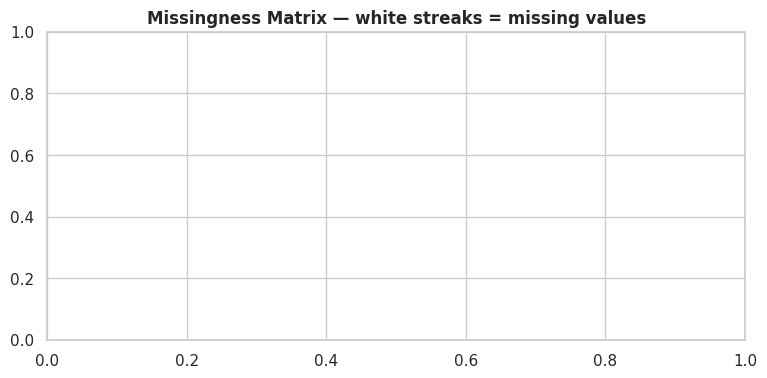

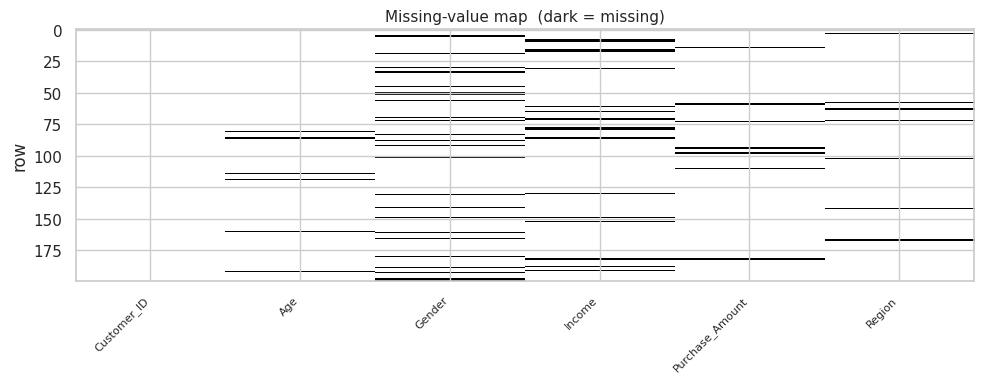

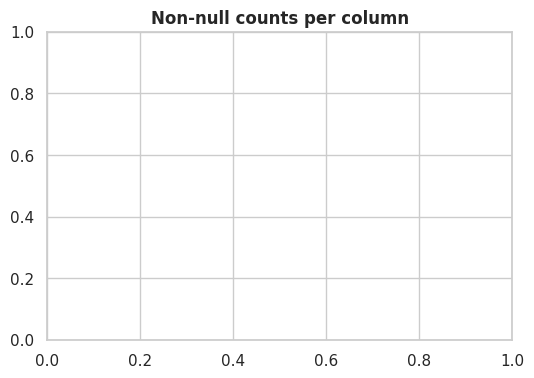

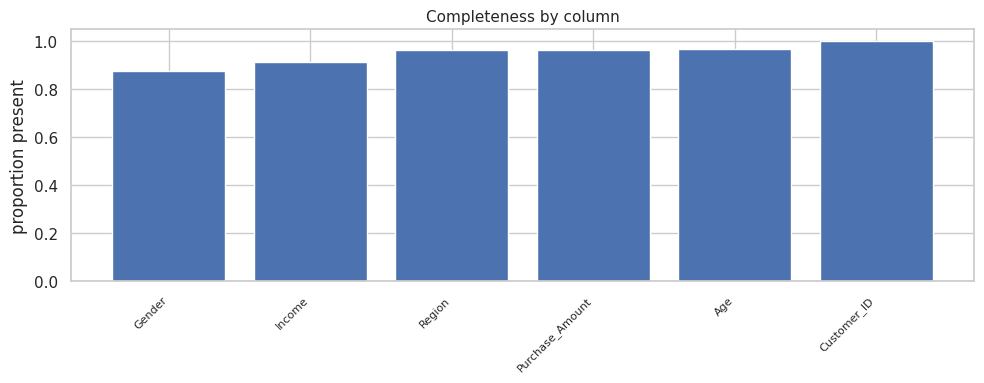

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
msno.matrix(df, ax=ax, sparkline=False)
ax.set_title("Missingness Matrix — white streaks = missing values", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
msno.bar(df, ax=ax)
ax.set_title("Non-null counts per column", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Deletion methods
The simplest "imputation" is to not impute at all — just drop the offending rows or columns. Only reasonable when missingness is small and MCAR.

In [5]:
# Listwise deletion (drop any row with ANY missing value)
df_listwise = df.dropna()
print(f"Original rows: {len(df)}  ->  After listwise deletion: {len(df_listwise)}  "
      f"({len(df) - len(df_listwise)} rows dropped, "
      f"{(1 - len(df_listwise)/len(df)):.1%} of the data)")

# Pairwise deletion isn't a DataFrame operation per se — it means each *calculation*
# (e.g. a correlation) uses whatever non-null pairs are available, rather than
# dropping a row just because ONE unrelated column is missing.
corr_pairwise = df[['Age', 'Income', 'Purchase_Amount']].corr()  # pandas .corr() does this automatically
print("\nCorrelation via pairwise-complete observations (pandas default):")
corr_pairwise

Original rows: 200  ->  After listwise deletion: 142  (58 rows dropped, 29.0% of the data)

Correlation via pairwise-complete observations (pandas default):


,Age,Income,Purchase_Amount
Age,1.000000,-0.117284,-0.168818
Income,-0.117284,1.000000,0.097527
Purchase_Amount,-0.168818,0.097527,1.000000


**Verdict:** Listwise deletion here throws away roughly a third of the dataset just because one of five columns had a gap — a lot of good information wasted for information that was actually recoverable. Deletion is a last resort, not a default.

## 3. Simple (univariate) imputation — numeric columns
We'll build a fresh copy of the dataframe for every technique so we can compare them fairly at the end, all starting from the *same* missing pattern.

In [6]:
from sklearn.impute import SimpleImputer

original_age = df['Age'].dropna()  # for before/after distribution comparison later
results = {}  # will store one imputed Series per technique for the final comparison

# --- 3a. Mean imputation ---
df_mean = df.copy()
df_mean['Age'] = SimpleImputer(strategy='mean').fit_transform(df_mean[['Age']])
results['Mean'] = df_mean['Age']

# --- 3b. Median imputation (robust to skew/outliers, often the safer numeric default) ---
df_median = df.copy()
df_median['Age'] = SimpleImputer(strategy='median').fit_transform(df_median[['Age']])
results['Median'] = df_median['Age']

# --- 3c. Constant / arbitrary-value imputation (flags the value as "was missing") ---
df_constant = df.copy()
df_constant['Age'] = SimpleImputer(strategy='constant', fill_value=-1).fit_transform(df_constant[['Age']])
results['Constant (-1)'] = df_constant['Age']

print("Mean age (original, non-missing only):  ", round(original_age.mean(), 2))
print("Median age (original, non-missing only):", round(original_age.median(), 2))
print("\nMissing Age rows filled by mean imputation:")
df_mean.loc[df['Age'].isnull(), ['Customer_ID', 'Age']].head()

Mean age (original, non-missing only):   38.6
Median age (original, non-missing only): 40.0

Missing Age rows filled by mean imputation:


,Customer_ID,Age
81,82,38.603093
86,87,38.603093
114,115,38.603093
119,120,38.603093
160,161,38.603093


In [7]:
# --- 3d. Random sample imputation ---
# Fills gaps by drawing random *observed* values from the same column.
# Big advantage over mean/median: it preserves the original variance and shape
# of the distribution, instead of piling everything onto one number.
df_random_sample = df.copy()
rng = np.random.default_rng(42)
missing_mask = df_random_sample['Age'].isnull()
n_missing = missing_mask.sum()
sampled_values = rng.choice(original_age.values, size=n_missing, replace=True)
df_random_sample.loc[missing_mask, 'Age'] = sampled_values
results['Random Sample'] = df_random_sample['Age']

# --- 3e. End-of-distribution imputation ---
# Deliberately fills with an extreme value (mean + 3*std) so that missingness
# itself becomes a distinguishable, modelable signal — common in credit scoring.
df_eod = df.copy()
eod_value = original_age.mean() + 3 * original_age.std()
df_eod['Age'] = df_eod['Age'].fillna(eod_value)
results['End-of-Distribution'] = df_eod['Age']
print(f"End-of-distribution fill value: {eod_value:.1f} years "
      f"(mean {original_age.mean():.1f} + 3 x std {original_age.std():.1f})")

End-of-distribution fill value: 75.8 years (mean 38.6 + 3 x std 12.4)


### Forward-fill, backward-fill & interpolation
These three are technically *sequence-aware* methods — they lean on the **row order** to borrow a neighbor's value. They shine on time series (e.g. daily temperature) but are genuinely questionable on cross-sectional customer data like this one, since row 42 has no real relationship to row 41. We still demonstrate them here for completeness — just note the caveat below.

In [8]:
# --- 3f. Forward fill (carries the last valid value forward) ---
df_ffill = df.copy()
df_ffill['Age'] = df_ffill['Age'].ffill()
results['Forward Fill'] = df_ffill['Age']

# --- 3g. Backward fill (carries the next valid value backward) ---
df_bfill = df.copy()
df_bfill['Age'] = df_bfill['Age'].bfill()
results['Backward Fill'] = df_bfill['Age']

# --- 3h. Linear interpolation (estimates a value along a straight line between neighbors) ---
df_interp = df.copy()
df_interp['Age'] = df_interp['Age'].interpolate(method='linear')
results['Interpolation'] = df_interp['Age']

print("NOTE: ffill/bfill/interpolate assume the row order is meaningful (e.g. a time axis).")
print("For this customer table the order is arbitrary, so mean/median/KNN are the more")
print("defensible choices in practice — but the mechanics are worth knowing cold for")
print("time-series datasets where they're the right tool for the job.")

NOTE: ffill/bfill/interpolate assume the row order is meaningful (e.g. a time axis).
For this customer table the order is arbitrary, so mean/median/KNN are the more
defensible choices in practice — but the mechanics are worth knowing cold for
time-series datasets where they're the right tool for the job.


## 4. Categorical column imputation — `Gender` and `Region`

In [9]:
# --- 4a. Mode (most frequent) imputation ---
df_mode = df.copy()
for col in ['Gender', 'Region']:
    mode_val = df_mode[col].mode()[0]
    df_mode[col] = df_mode[col].fillna(mode_val)
    print(f"{col}: filled {df[col].isnull().sum()} missing values with mode '{mode_val}'")

# --- 4b. "Missing" as its own category ---
# Instead of guessing, treat "unknown" as legitimate information — often the
# most honest option, since a customer *choosing* not to state gender/region
# may itself be a meaningful signal.
df_missing_cat = df.copy()
for col in ['Gender', 'Region']:
    df_missing_cat[col] = df_missing_cat[col].fillna('Missing')

print("\nRegion value counts after 'Missing'-category imputation:")
df_missing_cat['Region'].value_counts()

Gender: filled 25 missing values with mode 'Male'
Region: filled 7 missing values with mode 'West'

Region value counts after 'Missing'-category imputation:


Region
West       59
East       56
South      40
North      38
Missing     7
Name: count, dtype: int64

## 5. Missing indicator — don't just fill it, *flag* it
Whichever numeric technique you pick, it's good practice to also add a binary column recording *where* a value was originally missing. This lets a downstream model learn "missingness" as a feature in its own right — valuable when missingness is MAR/MNAR rather than pure noise.

In [10]:
df_final = df.copy()
df_final['Age_was_missing'] = df['Age'].isnull().astype(int)
df_final['Income_was_missing'] = df['Income'].isnull().astype(int)
df_final['Age'] = SimpleImputer(strategy='median').fit_transform(df_final[['Age']])
df_final['Income'] = SimpleImputer(strategy='median').fit_transform(df_final[['Income']])
df_final[['Customer_ID', 'Age', 'Age_was_missing', 'Income', 'Income_was_missing']].head(8)

,Customer_ID,Age,Age_was_missing,Income,Income_was_missing
0,1,55.0,0,70000.0,0
1,2,45.0,0,65000.0,0
2,3,31.0,0,30000.0,0
3,4,59.0,0,50000.0,0
4,5,24.0,0,70000.0,0
5,6,37.0,0,20000.0,0
6,7,55.0,0,25000.0,0
7,8,35.0,0,70000.0,0


## 6. Comparing every technique side-by-side
This is the payoff: a single plot showing how differently each method reshapes the `Age` distribution. Mean/median/constant/end-of-distribution all distort the shape in their own way; random sampling and interpolation stay closest to the original.

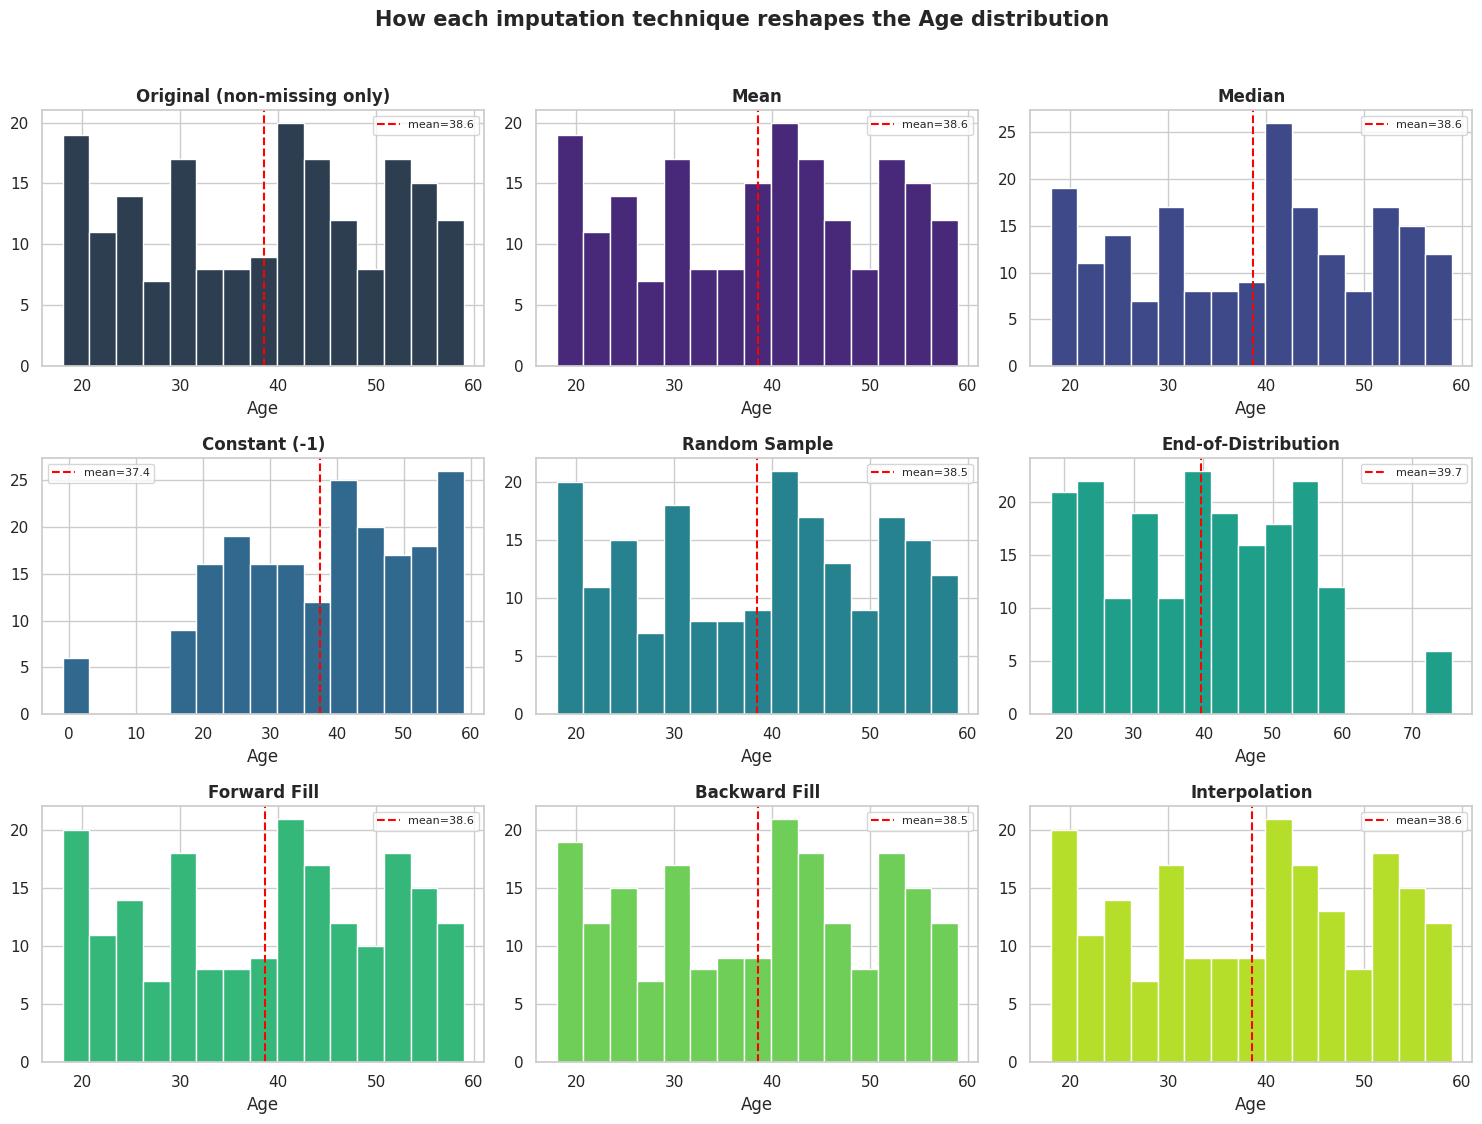

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

axes[0].hist(original_age, bins=15, color='#2c3e50', edgecolor='white')
axes[0].set_title("Original (non-missing only)", fontweight='bold')
axes[0].axvline(original_age.mean(), color='red', linestyle='--', label=f'mean={original_age.mean():.1f}')
axes[0].legend(fontsize=8)

for i, (name, series) in enumerate(results.items(), start=1):
    axes[i].hist(series, bins=15, color=sns.color_palette('viridis', len(results))[i-1], edgecolor='white')
    axes[i].set_title(name, fontweight='bold')
    axes[i].axvline(series.mean(), color='red', linestyle='--', label=f'mean={series.mean():.1f}')
    axes[i].legend(fontsize=8)

for ax in axes:
    ax.set_xlabel('Age')

plt.suptitle("How each imputation technique reshapes the Age distribution", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# Quantify the distortion: compare variance before vs after each technique
summary = pd.DataFrame({
    name: {'mean': series.mean(), 'std': series.std(), 'variance_retained_%': 100 * series.var() / original_age.var()}
    for name, series in results.items()
}).T.round(2)
summary.loc['Original (non-missing)'] = [original_age.mean(), original_age.std(), 100.0]
summary.sort_values('variance_retained_%', ascending=False)

,mean,std,variance_retained_%
Constant (-1),37.420000,13.960000,126.83
End-of-Distribution,39.720000,13.770000,123.31
Original (non-missing),38.603093,12.396397,100.00
Random Sample,38.480000,12.390000,99.90
Forward Fill,38.640000,12.370000,99.65
Backward Fill,38.520000,12.350000,99.32
Interpolation,38.580000,12.330000,99.00
Median,38.650000,12.210000,97.02
Mean,38.600000,12.210000,96.98


## Key takeaways

| Technique | Best used when... | Watch out for |
|---|---|---|
| **Mean** | Numeric, roughly symmetric, MCAR | Shrinks variance, sensitive to outliers |
| **Median** | Numeric, skewed or has outliers | Still shrinks variance, though less than mean |
| **Mode** | Categorical | Over-represents the majority class if missingness is high |
| **Constant / arbitrary value** | You explicitly want missingness to stand out to a model | Can create a fake "cluster" of values a model may over-trust |
| **Random sample** | You want to preserve the original variance/shape | Introduces randomness — not reproducible unless seeded |
| **End-of-distribution** | Credit scoring / explicit signal use cases | Deliberately distorts the tail of the distribution |
| **Forward/backward fill** | Time series with a real order | Meaningless on cross-sectional/tabular data |
| **Interpolation** | Time series / ordered numeric sequences | Same caveat as ffill/bfill |
| **Missing-category (categorical)** | You don't want to guess | Adds a new category a downstream encoder must handle |
| **Missing indicator** | Always, alongside any of the above | Adds a column — fine as long as you're not overloading a small dataset |

**Continue to:** `missing_values.ipynb` (Housing dataset) for the multivariate techniques — KNN Imputer and Iterative Imputer (MICE) — that use *other columns* to make a smarter guess than any univariate method can.

---
## Decision guide — which method, and how to justify it

Under exam pressure you need a rule, not a menu. Work down this list and stop at the first row that matches.

| Situation | Do this | Say this |
|---|---|---|
| Fewer than ~5% of rows affected, and they look random | `dropna()` | "The loss is negligible and the remaining sample stays representative." |
| Numeric column, roughly symmetric, no outliers | fill with the **mean** | "The mean uses all available information and the distribution is symmetric." |
| Numeric column, skewed or contains outliers | fill with the **median** | "The median is not distorted by the extreme values identified earlier." |
| Categorical / text column | fill with the **mode** | "The most frequent category is the best single guess for a nominal variable." |
| Time series or ordered data | `ffill()` / `interpolate()` | "Adjacent observations are the best estimate for a value in sequence." |
| The blank is itself informative (e.g. no second phone number) | fill with `'Unknown'` **and** add a missing-indicator column | "Missingness is meaningful here, so I preserve it rather than hiding it." |
| Column is more than ~50% empty | drop the **column** | "Too little signal remains to impute responsibly." |
| Several correlated numeric columns available | **KNN** or iterative imputation | "Using the correlated columns preserves the relationships a single-value fill would flatten." |

**The mark is in the justification, not the method.** Any of these is defensible; none of them is defensible
silently. Always print the missing counts before and after, so the effect of your choice is visible.

---

## Exam quick-reference

| To do this | Write this |
|---|---|
| Count blanks per column | `df.isnull().sum()` |
| As a percentage | `df.isnull().mean() * 100` |
| Total blank cells | `df.isnull().sum().sum()` |
| Rows with any blank | `df[df.isnull().any(axis=1)]` |
| Drop rows with any blank | `df.dropna()` |
| Drop only if a key column is blank | `df.dropna(subset=['Income'])` |
| Drop mostly-empty columns | `df.dropna(axis=1, thresh=len(df)*0.5)` |
| Fill with the mean | `s.fillna(s.mean())` |
| Fill with the median | `s.fillna(s.median())` |
| Fill text with the mode | `s.fillna(s.mode()[0])` |
| Different fill per column | `df.fillna({'a': 0, 'b': 'Unknown'})` |
| Carry the last value forward | `s.ffill()` |
| Interpolate between values | `s.interpolate()` |
| Flag that it was missing | `df['x_missing'] = df['x'].isnull()` |

### Adapting this in the exam

- Told 'treat the missing values'? Show the counts, choose a method, apply it, show the counts again. Four steps, every time.
- Numeric vs text decides mean/median vs mode — state which column type you're dealing with.
- Asked to drop instead of fill? `dropna(subset=[...])` targets specific columns rather than the whole row.

### Traps that cost marks

- `NaN` is not equal to anything, including itself. `df[df['x'] == np.nan]` always returns nothing — use `df['x'].isnull()`.
- `dropna()` with no arguments removes a row if **any** column is blank. On a wide table that can wipe out most of your data — check `.shape` before and after.
- `s.mode()` returns a Series (there can be ties). You need `s.mode()[0]`.
- `s.fillna(...)` returns a new Series. `df['col'].fillna(0)` on its own changes nothing — assign it back: `df['col'] = df['col'].fillna(0)`.
- Filling with the mean shrinks the variance and weakens correlations. Fine to do, but say that you know.
- `interpolate()` assumes the rows are in a meaningful order. On unsorted data it invents nonsense.